In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 그동안 imshow할때 aspect="auto"로 했어서 resize shape 관계없이 무조건 정방이미지로 시각화되었는데, resize 어떻게 되었는지 확인할 수 있게 aspect="equal"로 수정하고, 리사이즈 형상에 따라 성능영향차이가 생기는지 실험해보고자 함

In [ ]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [ ]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [ ]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [ ]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [ ]:

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(DEVICE)

cuda


In [ ]:
import os, json
from datetime import datetime
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))
optimizer_name = input("optimizer name (AdamW, adadelta, ...): ")

CFG = {
  "img_size": (128,128),
  "pad_idx": 112,
  "sos_idx": 0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": optimizer_name,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = input("model_name: ")
scheduler_name = input("scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): ")
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

epoch: 20
patience: 3
batch size: 16
optimizer name (AdamW, adadelta, ...): adamw
model_name: NAVER baseline (SATRN)
scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): circularlrbeta
min_lr: 5e-4
max_lr: 5e-4


In [ ]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/NAVER baseline (SATRN)_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [ ]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [ ]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [ ]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [ ]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [ ]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

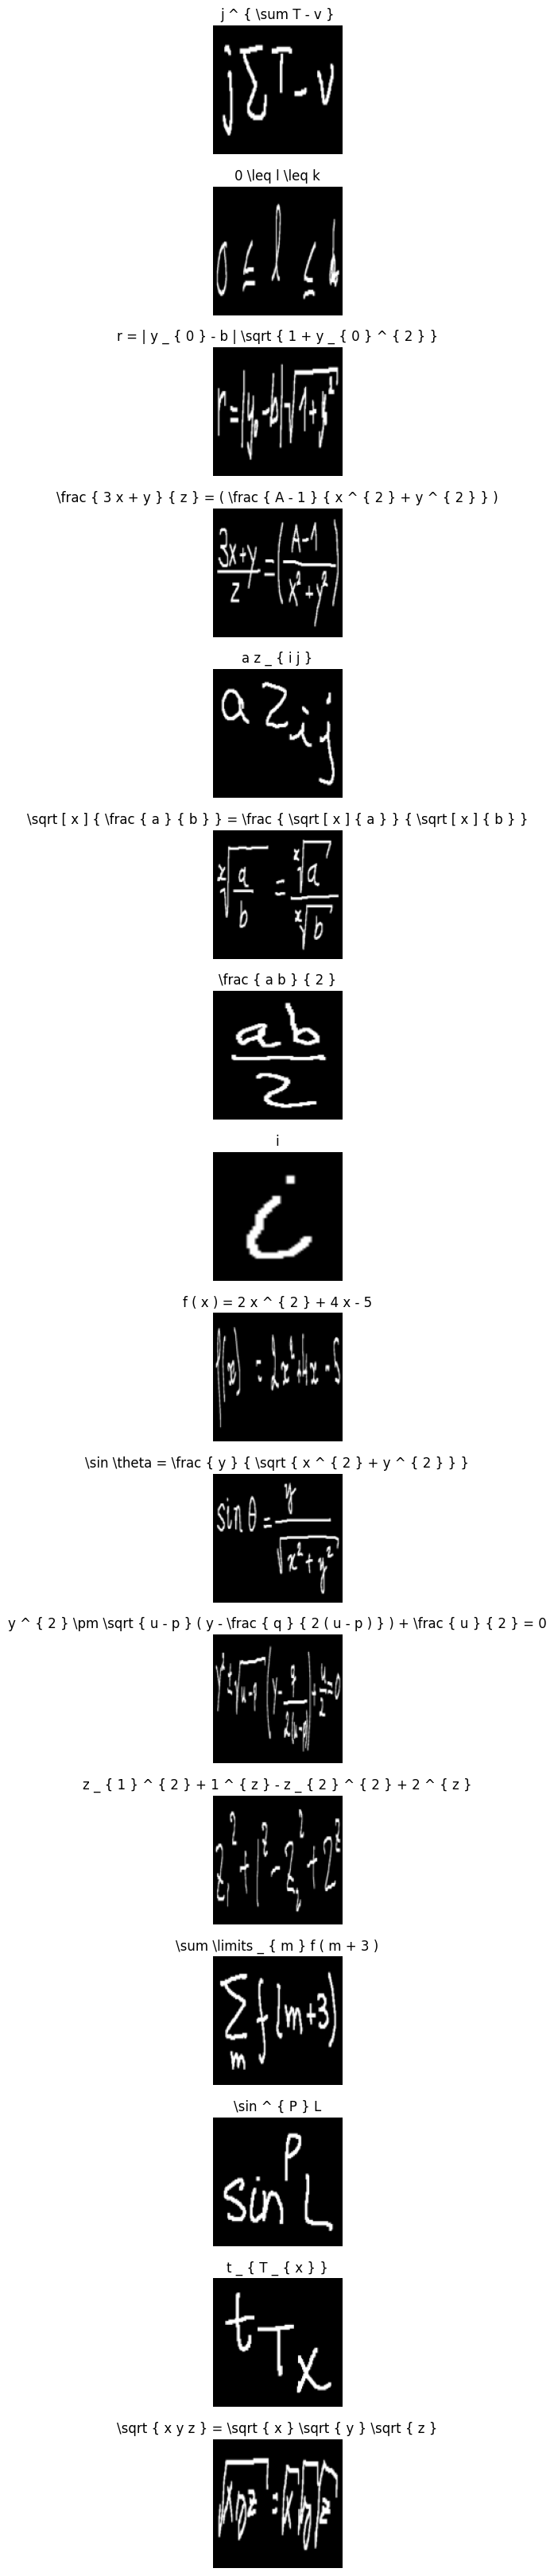

In [ ]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=bs, figure_width=1, figure_height=bs, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## SATRN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class BottleneckBlock(nn.Module):
    """
    Dense Bottleneck Block

    It contains two convolutional layers, a 1x1 and a 3x3.
    """

    def __init__(self, input_size, growth_rate, dropout_rate=0.2, num_bn=3):
        """
        Args:
            input_size (int): Number of channels of the input
            growth_rate (int): Number of new features being added. That is the ouput
                size of the last convolutional layer.
            dropout_rate (float, optional): Probability of dropout [Default: 0.2]
        """
        super(BottleneckBlock, self).__init__()
        inter_size = num_bn * growth_rate
        self.norm1 = nn.BatchNorm2d(input_size)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            input_size, inter_size, kernel_size=1, stride=1, bias=False
        )
        self.norm2 = nn.BatchNorm2d(inter_size)
        self.conv2 = nn.Conv2d(
            inter_size, growth_rate, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.conv1(self.relu(self.norm1(x)))
        out = self.conv2(self.relu(self.norm2(out)))
        out = self.dropout(out)
        return torch.cat([x, out], 1)


class TransitionBlock(nn.Module):
    """
    Transition Block

    A transition layer reduces the number of feature maps in-between two bottleneck
    blocks.
    """

    def __init__(self, input_size, output_size):
        """
        Args:
            input_size (int): Number of channels of the input
            output_size (int): Number of channels of the output
        """
        super(TransitionBlock, self).__init__()
        self.norm = nn.BatchNorm2d(input_size)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(
            input_size, output_size, kernel_size=1, stride=1, bias=False
        )
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        out = self.conv(self.relu(self.norm(x)))
        return self.pool(out)


class DenseBlock(nn.Module):
    """
    Dense block

    A dense block stacks several bottleneck blocks.
    """

    def __init__(self, input_size, growth_rate, depth, dropout_rate=0.2):
        """
        Args:
            input_size (int): Number of channels of the input
            growth_rate (int): Number of new features being added per bottleneck block
            depth (int): Number of bottleneck blocks
            dropout_rate (float, optional): Probability of dropout [Default: 0.2]
        """
        super(DenseBlock, self).__init__()
        layers = [
            BottleneckBlock(
                input_size + i * growth_rate, growth_rate, dropout_rate=dropout_rate
            )
            for i in range(depth)
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DeepCNN300(nn.Module):
    """
    This is specialized to the math formula recognition task
    - three convolutional layers to reduce the visual feature map size and to capture low-level visual features
    (128, 256) -> (8, 32) -> total 256 features
    - transformer layers cannot change the channel size, so it requires a wide feature dimension
    ***** this might be a point to be improved !!
    """

    def __init__(
        self, input_channel, num_in_features, output_channel=256, dropout_rate=0.2, depth=16, growth_rate=24
    ):
        super(DeepCNN300, self).__init__()
        self.conv0 = nn.Conv2d(
            input_channel,  # 3
            num_in_features,  # 48
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        self.norm0 = nn.BatchNorm2d(num_in_features)
        self.relu = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(
            kernel_size=2, stride=2
        )  # 1/4 (128, 128) -> (32, 32)
        num_features = num_in_features

        self.block1 = DenseBlock(
            num_features,  # 48
            growth_rate=growth_rate,  # 48 + growth_rate(24)*depth(16) -> 432
            depth=depth,  # 16?
            dropout_rate=0.2,
        )
        num_features = num_features + depth * growth_rate
        self.trans1 = TransitionBlock(num_features, num_features // 2)  # 16 x 16
        num_features = num_features // 2
        self.block2 = DenseBlock(
            num_features,  # 128
            growth_rate=growth_rate,  # 16
            depth=depth,  # 8
            dropout_rate=0.2,
        )
        num_features = num_features + depth * growth_rate
        self.trans2_norm = nn.BatchNorm2d(num_features)
        self.trans2_relu = nn.ReLU(inplace=True)
        self.trans2_conv = nn.Conv2d(
            num_features, num_features // 2, kernel_size=1, stride=1, bias=False  # 128
        )

    def forward(self, input):
        out = self.conv0(input)  # (H, V, )
        out = self.relu(self.norm0(out))
        out = self.max_pool(out)
        out = self.block1(out)
        out = self.trans1(out)
        out = self.block2(out)
        out_before_trans2 = self.trans2_relu(self.trans2_norm(out))
        out_A = self.trans2_conv(out_before_trans2)
        return out_A  # 128 x (16x16)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()

        self.temperature = temperature
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q, k, v, mask=None):

        attn = torch.matmul(q, k.transpose(2, 3)) / self.temperature
        if mask is not None:
            attn = attn.masked_fill(mask=mask, value=float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, q_channels, k_channels, head_num=8, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        self.q_channels = q_channels
        self.k_channels = k_channels
        self.head_dim = q_channels // head_num
        self.head_num = head_num

        self.q_linear = nn.Linear(q_channels, self.head_num * self.head_dim)
        self.k_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.v_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.attention = ScaledDotProductAttention(
            temperature=(self.head_num * self.head_dim) ** 0.5, dropout=dropout
        )
        self.out_linear = nn.Linear(self.head_num * self.head_dim, q_channels)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q, k, v, mask=None):
        b, q_len, k_len, v_len = q.size(0), q.size(1), k.size(1), v.size(1)
        q = (
            self.q_linear(q)
            .view(b, q_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )
        k = (
            self.k_linear(k)
            .view(b, k_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )
        v = (
            self.v_linear(v)
            .view(b, v_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )

        if mask is not None:
            mask = mask.unsqueeze(1)

        out, attn = self.attention(q, k, v, mask=mask)
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(b, q_len, self.head_num * self.head_dim)
        )
        out = self.out_linear(out)
        out = self.dropout(out)

        return out


class Feedforward(nn.Module):
    def __init__(self, filter_size=2048, hidden_dim=512, dropout=0.1):
        super(Feedforward, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, filter_size, True),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(filter_size, hidden_dim, True),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
        )

    def forward(self, input):
        return self.layers(input)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, input_size, filter_size, head_num, dropout_rate=0.2):
        super(TransformerEncoderLayer, self).__init__()

        self.attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=input_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.attention_norm = nn.LayerNorm(normalized_shape=input_size)
        self.feedforward_layer = Feedforward(
            filter_size=filter_size, hidden_dim=input_size
        )
        self.feedforward_norm = nn.LayerNorm(normalized_shape=input_size)

    def forward(self, input):

        att = self.attention_layer(input, input, input)
        out = self.attention_norm(att + input)

        ff = self.feedforward_layer(out)
        out = self.feedforward_norm(ff + out)
        return out


class PositionalEncoding2D(nn.Module):
    def __init__(self, in_channels, max_h=64, max_w=128, dropout=0.1):
        super(PositionalEncoding2D, self).__init__()

        self.h_position_encoder = self.generate_encoder(in_channels // 2, max_h)
        self.w_position_encoder = self.generate_encoder(in_channels // 2, max_w)

        self.h_linear = nn.Linear(in_channels // 2, in_channels // 2)
        self.w_linear = nn.Linear(in_channels // 2, in_channels // 2)

        self.dropout = nn.Dropout(p=dropout)

    def generate_encoder(self, in_channels, max_len):
        pos = torch.arange(max_len).float().unsqueeze(1)
        i = torch.arange(in_channels).float().unsqueeze(0)
        angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / in_channels)
        position_encoder = pos * angle_rates
        position_encoder[:, 0::2] = torch.sin(position_encoder[:, 0::2])
        position_encoder[:, 1::2] = torch.cos(position_encoder[:, 1::2])
        return position_encoder  # (Max_len, In_channel)

    def forward(self, input):
        ### Require DEBUG
        b, c, h, w = input.size()
        h_pos_encoding = (
            self.h_position_encoder[:h, :].unsqueeze(1).to(input.get_device())
        )
        h_pos_encoding = self.h_linear(h_pos_encoding)  # [H, 1, D]

        w_pos_encoding = (
            self.w_position_encoder[:w, :].unsqueeze(0).to(input.get_device())
        )
        w_pos_encoding = self.w_linear(w_pos_encoding)  # [1, W, D]

        h_pos_encoding = h_pos_encoding.expand(-1, w, -1)   # h, w, c/2
        w_pos_encoding = w_pos_encoding.expand(h, -1, -1)   # h, w, c/2

        pos_encoding = torch.cat([h_pos_encoding, w_pos_encoding], dim=2)  # [H, W, 2*D]

        pos_encoding = pos_encoding.permute(2, 0, 1)  # [2*D, H, W]

        out = input + pos_encoding.unsqueeze(0)
        out = self.dropout(out)

        return out


class TransformerEncoderFor2DFeatures(nn.Module):
    """
    Transformer Encoder for Image
    1) ShallowCNN : low-level visual feature identification and dimension reduction
    2) Positional Encoding : adding positional information to the visual features
    3) Transformer Encoders : self-attention layers for the 2D feature maps
    """

    def __init__(
        self,
        input_size,
        hidden_dim,
        filter_size,
        head_num,
        layer_num,
        dropout_rate=0.1,
        checkpoint=None,
    ):
        super(TransformerEncoderFor2DFeatures, self).__init__()

        self.shallow_cnn = DeepCNN300(
            input_size,
            num_in_features=48,
            output_channel=hidden_dim,
            dropout_rate=dropout_rate,
        )
        self.positional_encoding = PositionalEncoding2D(hidden_dim)
        self.attention_layers = nn.ModuleList(
            [
                TransformerEncoderLayer(hidden_dim, filter_size, head_num, dropout_rate)
                for _ in range(layer_num)
            ]
        )
        if checkpoint is not None:
            self.load_state_dict(checkpoint)

    def forward(self, input):

        out = self.shallow_cnn(input)  # [b, c, h, w]
        out = self.positional_encoding(out)  # [b, c, h, w]

        # flatten
        b, c, h, w = out.size()
        out = out.view(b, c, h * w).transpose(1, 2)  # [b, h x w, c]

        for layer in self.attention_layers:
            out = layer(out)
        return out


class TransformerDecoderLayer(nn.Module):
    def __init__(self, input_size, src_size, filter_size, head_num, dropout_rate=0.2):
        super(TransformerDecoderLayer, self).__init__()

        self.self_attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=input_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.self_attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=src_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.feedforward_layer = Feedforward(
            filter_size=filter_size, hidden_dim=input_size
        )
        self.feedforward_norm = nn.LayerNorm(normalized_shape=input_size)

    def forward(self, tgt, tgt_prev, src, tgt_mask):

        if tgt_prev == None:  # Train
            att = self.self_attention_layer(tgt, tgt, tgt, tgt_mask)
            out = self.self_attention_norm(att + tgt)

            att = self.attention_layer(tgt, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        else:
            tgt_prev = torch.cat([tgt_prev, tgt], 1)
            att = self.self_attention_layer(tgt, tgt_prev, tgt_prev, tgt_mask)
            out = self.self_attention_norm(att + tgt)

            att = self.attention_layer(tgt, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        return out


class PositionEncoder1D(nn.Module):
    def __init__(self, in_channels, max_len=500, dropout=0.1):
        super(PositionEncoder1D, self).__init__()

        self.position_encoder = self.generate_encoder(in_channels, max_len)
        self.position_encoder = self.position_encoder.unsqueeze(0)
        self.dropout = nn.Dropout(p=dropout)

    def generate_encoder(self, in_channels, max_len):
        pos = torch.arange(max_len).float().unsqueeze(1)

        i = torch.arange(in_channels).float().unsqueeze(0)
        angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / in_channels)

        position_encoder = pos * angle_rates
        position_encoder[:, 0::2] = torch.sin(position_encoder[:, 0::2])
        position_encoder[:, 1::2] = torch.cos(position_encoder[:, 1::2])

        return position_encoder

    def forward(self, x, point=-1):
        if point == -1:
            out = x + self.position_encoder[:, : x.size(1), :].to(x.get_device())
            out = self.dropout(out)
        else:
            out = x + self.position_encoder[:, point, :].unsqueeze(1).to(x.get_device())
        return out


class TransformerDecoder(nn.Module):
    def __init__(
        self,
        num_classes,
        src_dim,
        hidden_dim,
        filter_dim,
        head_num,
        dropout_rate,
        pad_id,
        st_id,
        layer_num=1,
        checkpoint=None,
    ):
        super(TransformerDecoder, self).__init__()

        self.embedding = nn.Embedding(num_classes + 1, hidden_dim)
        self.hidden_dim = hidden_dim
        self.filter_dim = filter_dim
        self.num_classes = num_classes
        self.layer_num = layer_num

        self.pos_encoder = PositionEncoder1D(
            in_channels=hidden_dim, dropout=dropout_rate
        )

        self.attention_layers = nn.ModuleList(
            [
                TransformerDecoderLayer(
                    hidden_dim, src_dim, filter_dim, head_num, dropout_rate
                )
                for _ in range(layer_num)
            ]
        )
        self.generator = nn.Linear(hidden_dim, num_classes)

        self.pad_id = pad_id
        self.st_id = st_id

        if checkpoint is not None:
            self.load_state_dict(checkpoint)

    def pad_mask(self, text):
        pad_mask = text == self.pad_id
        pad_mask[:, 0] = False
        pad_mask = pad_mask.unsqueeze(1)

        return pad_mask

    def order_mask(self, length):
        order_mask = torch.triu(torch.ones(length, length), diagonal=1).bool()
        order_mask = order_mask.unsqueeze(0).to(device)
        return order_mask

    def text_embedding(self, texts):
        tgt = self.embedding(texts)
        tgt *= math.sqrt(tgt.size(2))

        return tgt

    def forward(
        self, src, text, is_train=True, batch_max_length=50, teacher_forcing_ratio=1.0
    ):

        if is_train and random.random() < teacher_forcing_ratio:
            tgt = self.text_embedding(text)
            tgt = self.pos_encoder(tgt)
            tgt_mask = self.pad_mask(text) | self.order_mask(text.size(1))
            for layer in self.attention_layers:
                tgt = layer(tgt, None, src, tgt_mask)
            out = self.generator(tgt)
        else:
            out = []
            num_steps = batch_max_length - 1
            target = torch.LongTensor(src.size(0)).fill_(self.st_id).to(device) # [START] token
            features = [None] * self.layer_num

            for t in range(num_steps):
                target = target.unsqueeze(1)
                tgt = self.text_embedding(target)
                tgt = self.pos_encoder(tgt, point=t)
                tgt_mask = self.order_mask(t + 1)
                tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [1, (l+1)]
                for l, layer in enumerate(self.attention_layers):
                    tgt = layer(tgt, features[l], src, tgt_mask)
                    features[l] = (
                        tgt if features[l] == None else torch.cat([features[l], tgt], 1)
                    )

                _out = self.generator(tgt)  # [b, 1, c]
                target = torch.argmax(_out[:, -1:, :], dim=-1)  # [b, 1]
                target = target.squeeze(1)   # [b]
                out.append(_out)

            out = torch.stack(out, dim=1).to(device)    # [b, max length, 1, class length]
            out = out.squeeze(2)    # [b, max length, class length]

        return out


class SATRN(nn.Module):
    def __init__(self, checkpoint=None):
        super(SATRN, self).__init__()

        self.encoder = TransformerEncoderFor2DFeatures(
            input_size=1,
            hidden_dim=300,
            filter_size=600,
            head_num=8,
            layer_num=6,
            dropout_rate=0.1,
        )

        self.decoder = TransformerDecoder(
            num_classes=CFG["model"]["vocab_size"],
            src_dim=300,
            hidden_dim=128,
            filter_dim=512,
            head_num=8,
            dropout_rate=0.1,
            pad_id=CFG["pad_idx"],
            st_id=CFG["sos_idx"],
            layer_num=1,
        )

        self.criterion = nn.CrossEntropyLoss(ignore_index = CFG["pad_idx"])

        if checkpoint:
            self.load_state_dict(checkpoint)

    def forward(self, input, expected, is_train, teacher_forcing_ratio):
        enc_result = self.encoder(input)
        dec_result = self.decoder(
            enc_result,
            expected[:, :-1],
            is_train,
            expected.size(1),
            teacher_forcing_ratio,
        )
        return dec_result

## Spatial Transformer

In [ ]:
# # Origin: https://github.com/clovaai/deep-text-recognition-benchmark/blob/master/modules/transformation.py

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# class TPS_SpatialTransformerNetwork(nn.Module):
#     """ Rectification Network of RARE, namely TPS based STN """

#     def __init__(self, F, I_size, I_r_size, I_channel_num=1):
#         """ Based on RARE TPS
#         input:
#             batch_I: Batch Input Image [batch_size x I_channel_num x I_height x I_width]
#             I_size : (height, width) of the input image I
#             I_r_size : (height, width) of the rectified image I_r
#             I_channel_num : the number of channels of the input image I
#         output:
#             batch_I_r: rectified image [batch_size x I_channel_num x I_r_height x I_r_width]
#         """
#         super(TPS_SpatialTransformerNetwork, self).__init__()
#         self.F = F
#         self.I_size = I_size
#         self.I_r_size = I_r_size  # = (I_r_height, I_r_width)
#         self.I_channel_num = I_channel_num
#         self.LocalizationNetwork = LocalizationNetwork(self.F, self.I_channel_num)
#         self.GridGenerator = GridGenerator(self.F, self.I_r_size)

#     def forward(self, batch_I):
#         batch_C_prime = self.LocalizationNetwork(batch_I)  # batch_size x K x 2
#         build_P_prime = self.GridGenerator.build_P_prime(batch_C_prime)  # batch_size x n (= I_r_width x I_r_height) x 2
#         build_P_prime_reshape = build_P_prime.reshape([build_P_prime.size(0), self.I_r_size[0], self.I_r_size[1], 2])

#         if torch.__version__ > "1.2.0":
#             batch_I_r = F.grid_sample(batch_I, build_P_prime_reshape, padding_mode='border', align_corners=True)
#         else:
#             batch_I_r = F.grid_sample(batch_I, build_P_prime_reshape, padding_mode='border')

#         return batch_I_r


# class LocalizationNetwork(nn.Module):
#     """ Localization Network of RARE, which predicts C' (K x 2) from I (I_width x I_height) """

#     def __init__(self, F, I_channel_num):
#         super(LocalizationNetwork, self).__init__()
#         self.F = F
#         self.I_channel_num = I_channel_num
#         self.conv = nn.Sequential(
#             nn.Conv2d(in_channels=self.I_channel_num, out_channels=64, kernel_size=3, stride=1, padding=1,
#                       bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
#             nn.MaxPool2d(2, 2),  # batch_size x 64 x I_height/2 x I_width/2
#             nn.Conv2d(64, 128, 3, 1, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
#             nn.MaxPool2d(2, 2),  # batch_size x 128 x I_height/4 x I_width/4
#             nn.Conv2d(128, 256, 3, 1, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
#             nn.MaxPool2d(2, 2),  # batch_size x 256 x I_height/8 x I_width/8
#             nn.Conv2d(256, 512, 3, 1, 1, bias=False), nn.BatchNorm2d(512), nn.ReLU(True),
#             nn.AdaptiveAvgPool2d(1)  # batch_size x 512
#         )

#         self.localization_fc1 = nn.Sequential(nn.Linear(512, 256), nn.ReLU(True))
#         self.localization_fc2 = nn.Linear(256, self.F * 2)

#         # Init fc2 in LocalizationNetwork
#         self.localization_fc2.weight.data.fill_(0)
#         """ see RARE paper Fig. 6 (a) """
#         ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
#         ctrl_pts_y_top = np.linspace(0.0, -1.0, num=int(F / 2))
#         ctrl_pts_y_bottom = np.linspace(1.0, 0.0, num=int(F / 2))
#         ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
#         ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
#         initial_bias = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
#         self.localization_fc2.bias.data = torch.from_numpy(initial_bias).float().view(-1)

#     def forward(self, batch_I):
#         """
#         input:     batch_I : Batch Input Image [batch_size x I_channel_num x I_height x I_width]
#         output:    batch_C_prime : Predicted coordinates of fiducial points for input batch [batch_size x F x 2]
#         """
#         batch_size = batch_I.size(0)
#         features = self.conv(batch_I).view(batch_size, -1)
#         batch_C_prime = self.localization_fc2(self.localization_fc1(features)).view(batch_size, self.F, 2)
#         return batch_C_prime


# class GridGenerator(nn.Module):
#     """ Grid Generator of RARE, which produces P_prime by multipling T with P """

#     def __init__(self, F, I_r_size):
#         """ Generate P_hat and inv_delta_C for later """
#         super(GridGenerator, self).__init__()
#         self.eps = 1e-6
#         self.I_r_height, self.I_r_width = I_r_size
#         self.F = F
#         self.C = self._build_C(self.F)  # F x 2
#         self.P = self._build_P(self.I_r_width, self.I_r_height)
#         ## for multi-gpu, you need register buffer
#         self.register_buffer("inv_delta_C", torch.tensor(self._build_inv_delta_C(self.F, self.C)).float())  # F+3 x F+3
#         self.register_buffer("P_hat", torch.tensor(self._build_P_hat(self.F, self.C, self.P)).float())  # n x F+3
#         ## for fine-tuning with different image width, you may use below instead of self.register_buffer
#         #self.inv_delta_C = torch.tensor(self._build_inv_delta_C(self.F, self.C)).float().cuda()  # F+3 x F+3
#         #self.P_hat = torch.tensor(self._build_P_hat(self.F, self.C, self.P)).float().cuda()  # n x F+3

#     def _build_C(self, F):
#         """ Return coordinates of fiducial points in I_r; C """
#         ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
#         ctrl_pts_y_top = -1 * np.ones(int(F / 2))
#         ctrl_pts_y_bottom = np.ones(int(F / 2))
#         ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
#         ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
#         C = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
#         return C  # F x 2

#     def _build_inv_delta_C(self, F, C):
#         """ Return inv_delta_C which is needed to calculate T """
#         hat_C = np.zeros((F, F), dtype=float)  # F x F
#         for i in range(0, F):
#             for j in range(i, F):
#                 r = np.linalg.norm(C[i] - C[j])
#                 hat_C[i, j] = r
#                 hat_C[j, i] = r
#         np.fill_diagonal(hat_C, 1)
#         hat_C = (hat_C ** 2) * np.log(hat_C)
#         # print(C.shape, hat_C.shape)
#         delta_C = np.concatenate(  # F+3 x F+3
#             [
#                 np.concatenate([np.ones((F, 1)), C, hat_C], axis=1),  # F x F+3
#                 np.concatenate([np.zeros((2, 3)), np.transpose(C)], axis=1),  # 2 x F+3
#                 np.concatenate([np.zeros((1, 3)), np.ones((1, F))], axis=1)  # 1 x F+3
#             ],
#             axis=0
#         )
#         inv_delta_C = np.linalg.inv(delta_C)
#         return inv_delta_C  # F+3 x F+3

#     def _build_P(self, I_r_width, I_r_height):
#         I_r_grid_x = (np.arange(-I_r_width, I_r_width, 2) + 1.0) / I_r_width  # self.I_r_width
#         I_r_grid_y = (np.arange(-I_r_height, I_r_height, 2) + 1.0) / I_r_height  # self.I_r_height
#         P = np.stack(  # self.I_r_width x self.I_r_height x 2
#             np.meshgrid(I_r_grid_x, I_r_grid_y),
#             axis=2
#         )
#         return P.reshape([-1, 2])  # n (= self.I_r_width x self.I_r_height) x 2

#     def _build_P_hat(self, F, C, P):
#         n = P.shape[0]  # n (= self.I_r_width x self.I_r_height)
#         P_tile = np.tile(np.expand_dims(P, axis=1), (1, F, 1))  # n x 2 -> n x 1 x 2 -> n x F x 2
#         C_tile = np.expand_dims(C, axis=0)  # 1 x F x 2
#         P_diff = P_tile - C_tile  # n x F x 2
#         rbf_norm = np.linalg.norm(P_diff, ord=2, axis=2, keepdims=False)  # n x F
#         rbf = np.multiply(np.square(rbf_norm), np.log(rbf_norm + self.eps))  # n x F
#         P_hat = np.concatenate([np.ones((n, 1)), P, rbf], axis=1)
#         return P_hat  # n x F+3

#     def build_P_prime(self, batch_C_prime):
#         """ Generate Grid from batch_C_prime [batch_size x F x 2] """
#         batch_size = batch_C_prime.size(0)
#         batch_inv_delta_C = self.inv_delta_C.repeat(batch_size, 1, 1)
#         batch_P_hat = self.P_hat.repeat(batch_size, 1, 1)
#         batch_C_prime_with_zeros = torch.cat((batch_C_prime, torch.zeros(
#             batch_size, 3, 2).float().to(device)), dim=1)  # batch_size x F+3 x 2
#         batch_T = torch.bmm(batch_inv_delta_C, batch_C_prime_with_zeros)  # batch_size x F+3 x 2
#         batch_P_prime = torch.bmm(batch_P_hat, batch_T)  # batch_size x n x 2
#         return batch_P_prime  # batch_size x n x 2


# Train


In [ ]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

# Scheduler

In [ ]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [ ]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [ ]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [ ]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [ ]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = SATRN().to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/20: 100%|██████████| 442/442 [01:52<00:00,  3.94it/s, expr0=0, expr1=0.182, expr2=0.273, expr3=0.273, loss=2.61, lr=9.98e-5, wer=1.02]



[Train Epoch 1] Loss: 3.4133, Expr@0: 0.0000, Expr@1: 0.0379, Expr@2: 0.0674, Expr@3: 0.1082, WER: 2.7866


[Valid] Epoch 1/20: 100%|██████████| 1767/1767 [21:02<00:00,  1.40it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.23, wer=0.889]



[Valid Epoch 1] Loss: 3.4409, Expr@0: 0.0000, Expr@1: 0.0509, Expr@2: 0.0928, Expr@3: 0.1596, WER: 0.9095
Best model saved.



[Train] Epoch 2/20: 100%|██████████| 442/442 [01:49<00:00,  4.04it/s, expr0=0, expr1=0, expr2=0.0909, expr3=0.182, loss=2.62, lr=0.00015, wer=0.761]


...


[Valid Epoch 19] Loss: 1.8272, Expr@0: 0.1019, Expr@1: 0.1902, Expr@2: 0.2609, Expr@3: 0.3435, WER: 0.5120
Best model saved.



[Train] Epoch 20/20: 100%|██████████| 442/442 [01:52<00:00,  3.92it/s, expr0=0, expr1=0.182, expr2=0.364, expr3=0.455, loss=2.14, lr=6.12e-7, wer=0.563]



[Train Epoch 20] Loss: 1.3375, Expr@0: 0.1497, Expr@1: 0.2626, Expr@2: 0.3560, Expr@3: 0.4254, WER: 0.5349


[Valid] Epoch 20/20: 100%|██████████| 1767/1767 [01:46<00:00, 16.53it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.3, wer=0.733]



[Valid Epoch 20] Loss: 1.8164, Expr@0: 0.1064, Expr@1: 0.1947, Expr@2: 0.2756, Expr@3: 0.3554, WER: 0.5025
Best model saved.



In [ ]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/NAVER baseline (SATRN)_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/train_log.json


In [ ]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

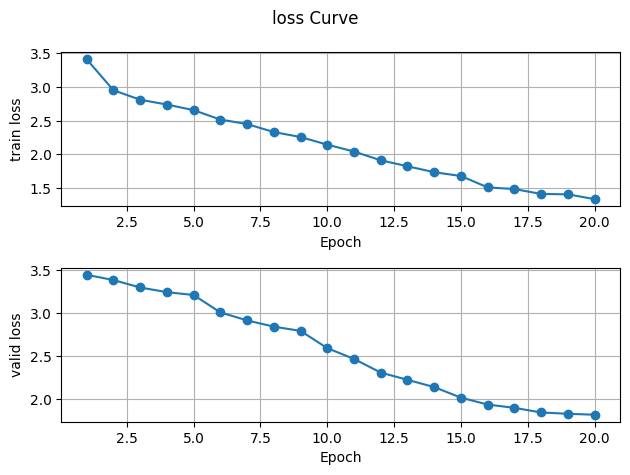

In [ ]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

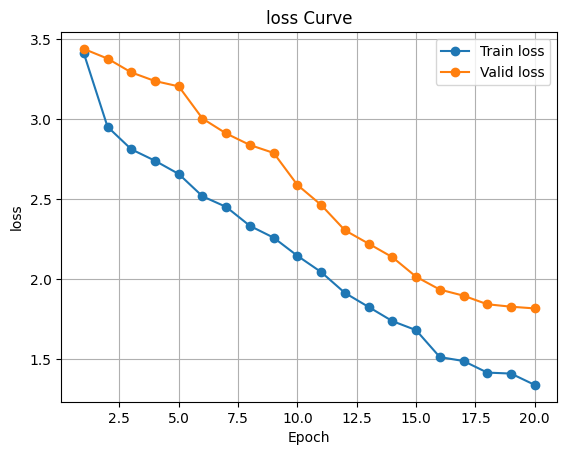

In [ ]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

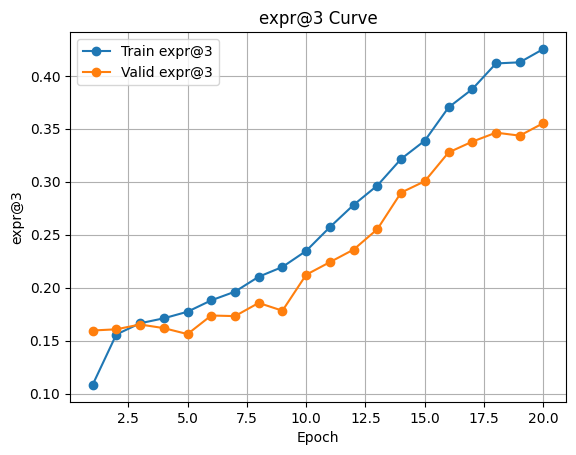

In [ ]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

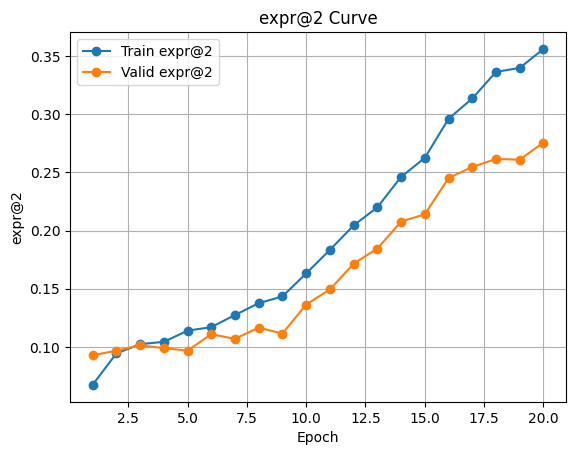

In [ ]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

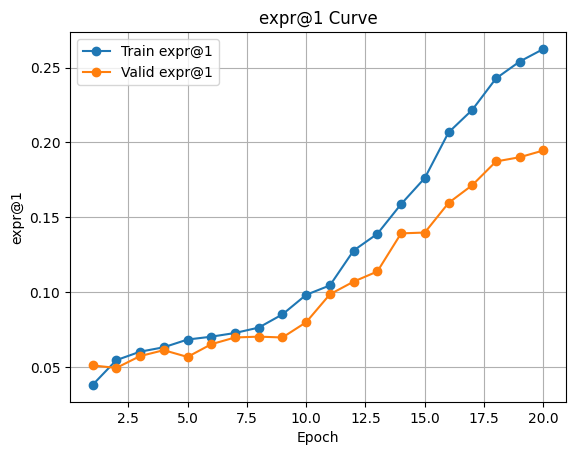

In [ ]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

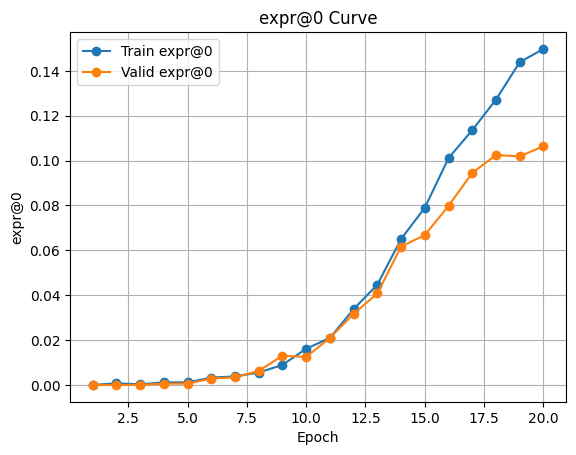

In [ ]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

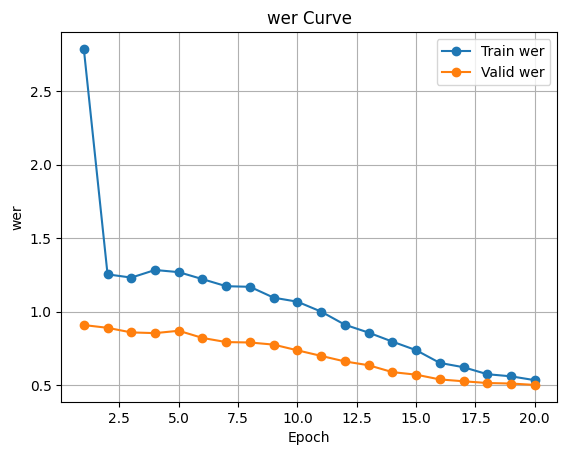

In [ ]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

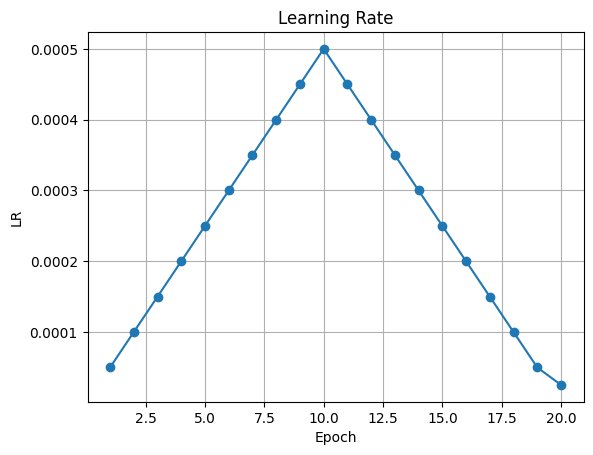

In [ ]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [ ]:
# best_model.pth 가져오기

model = SATRN().to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [05:27<00:00,  3.01it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.38, wer=0.779]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [06:15<00:00,  3.05it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.76, wer=0.796]


CROHME_2019


...

[Test] batch:1198/1199: 100%|██████████| 1199/1199 [06:35<00:00,  3.03it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=6.45, wer=0.967]


IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [05:18<00:00,  2.97it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.88, wer=0.909]


IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [05:07<00:00,  3.08it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.58, wer=1.03]


# Prediction 샘플 시각화

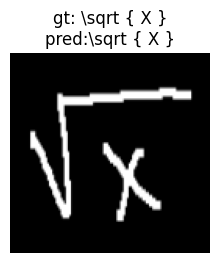

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

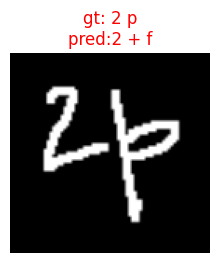

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

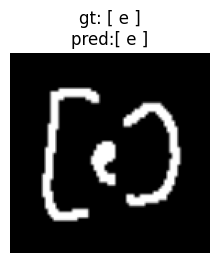

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

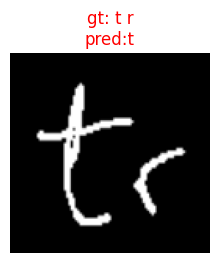

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

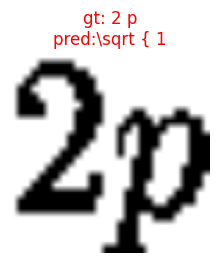

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

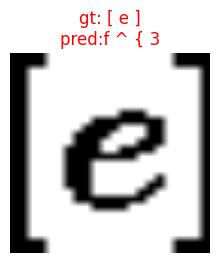

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

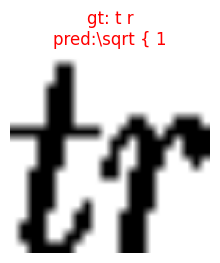

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

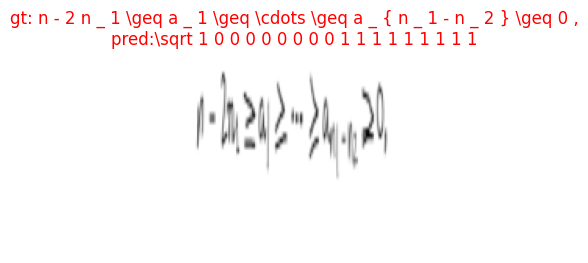

In [ ]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

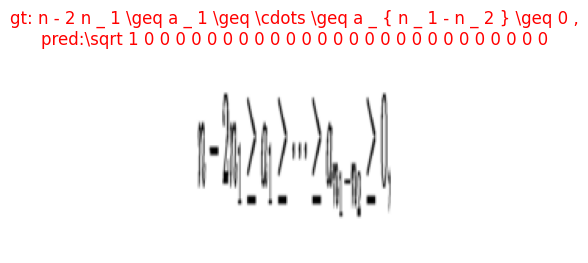

In [ ]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)